<a href="https://colab.research.google.com/github/shravaniruikar/BML/blob/main/BML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train the system using breast cancer dataset obtained from UCIML repository, determine using KNN classifier.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('breast-cancer.csv')

# Drop 'id' column
df.drop('id', axis=1, inplace=True)

# Check for missing values
print(df.isnull().sum())


diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
# Encode 'diagnosis' (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


In [ ]:
# Remove duplicate rows if any
df.drop_duplicates(inplace=True)


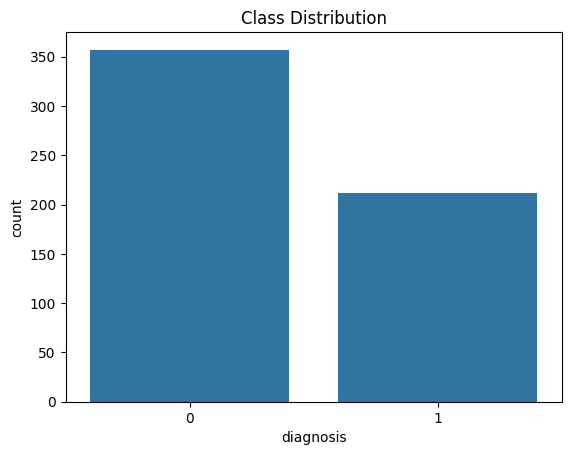

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='diagnosis', data=df)
plt.title('Class Distribution')
plt.show()


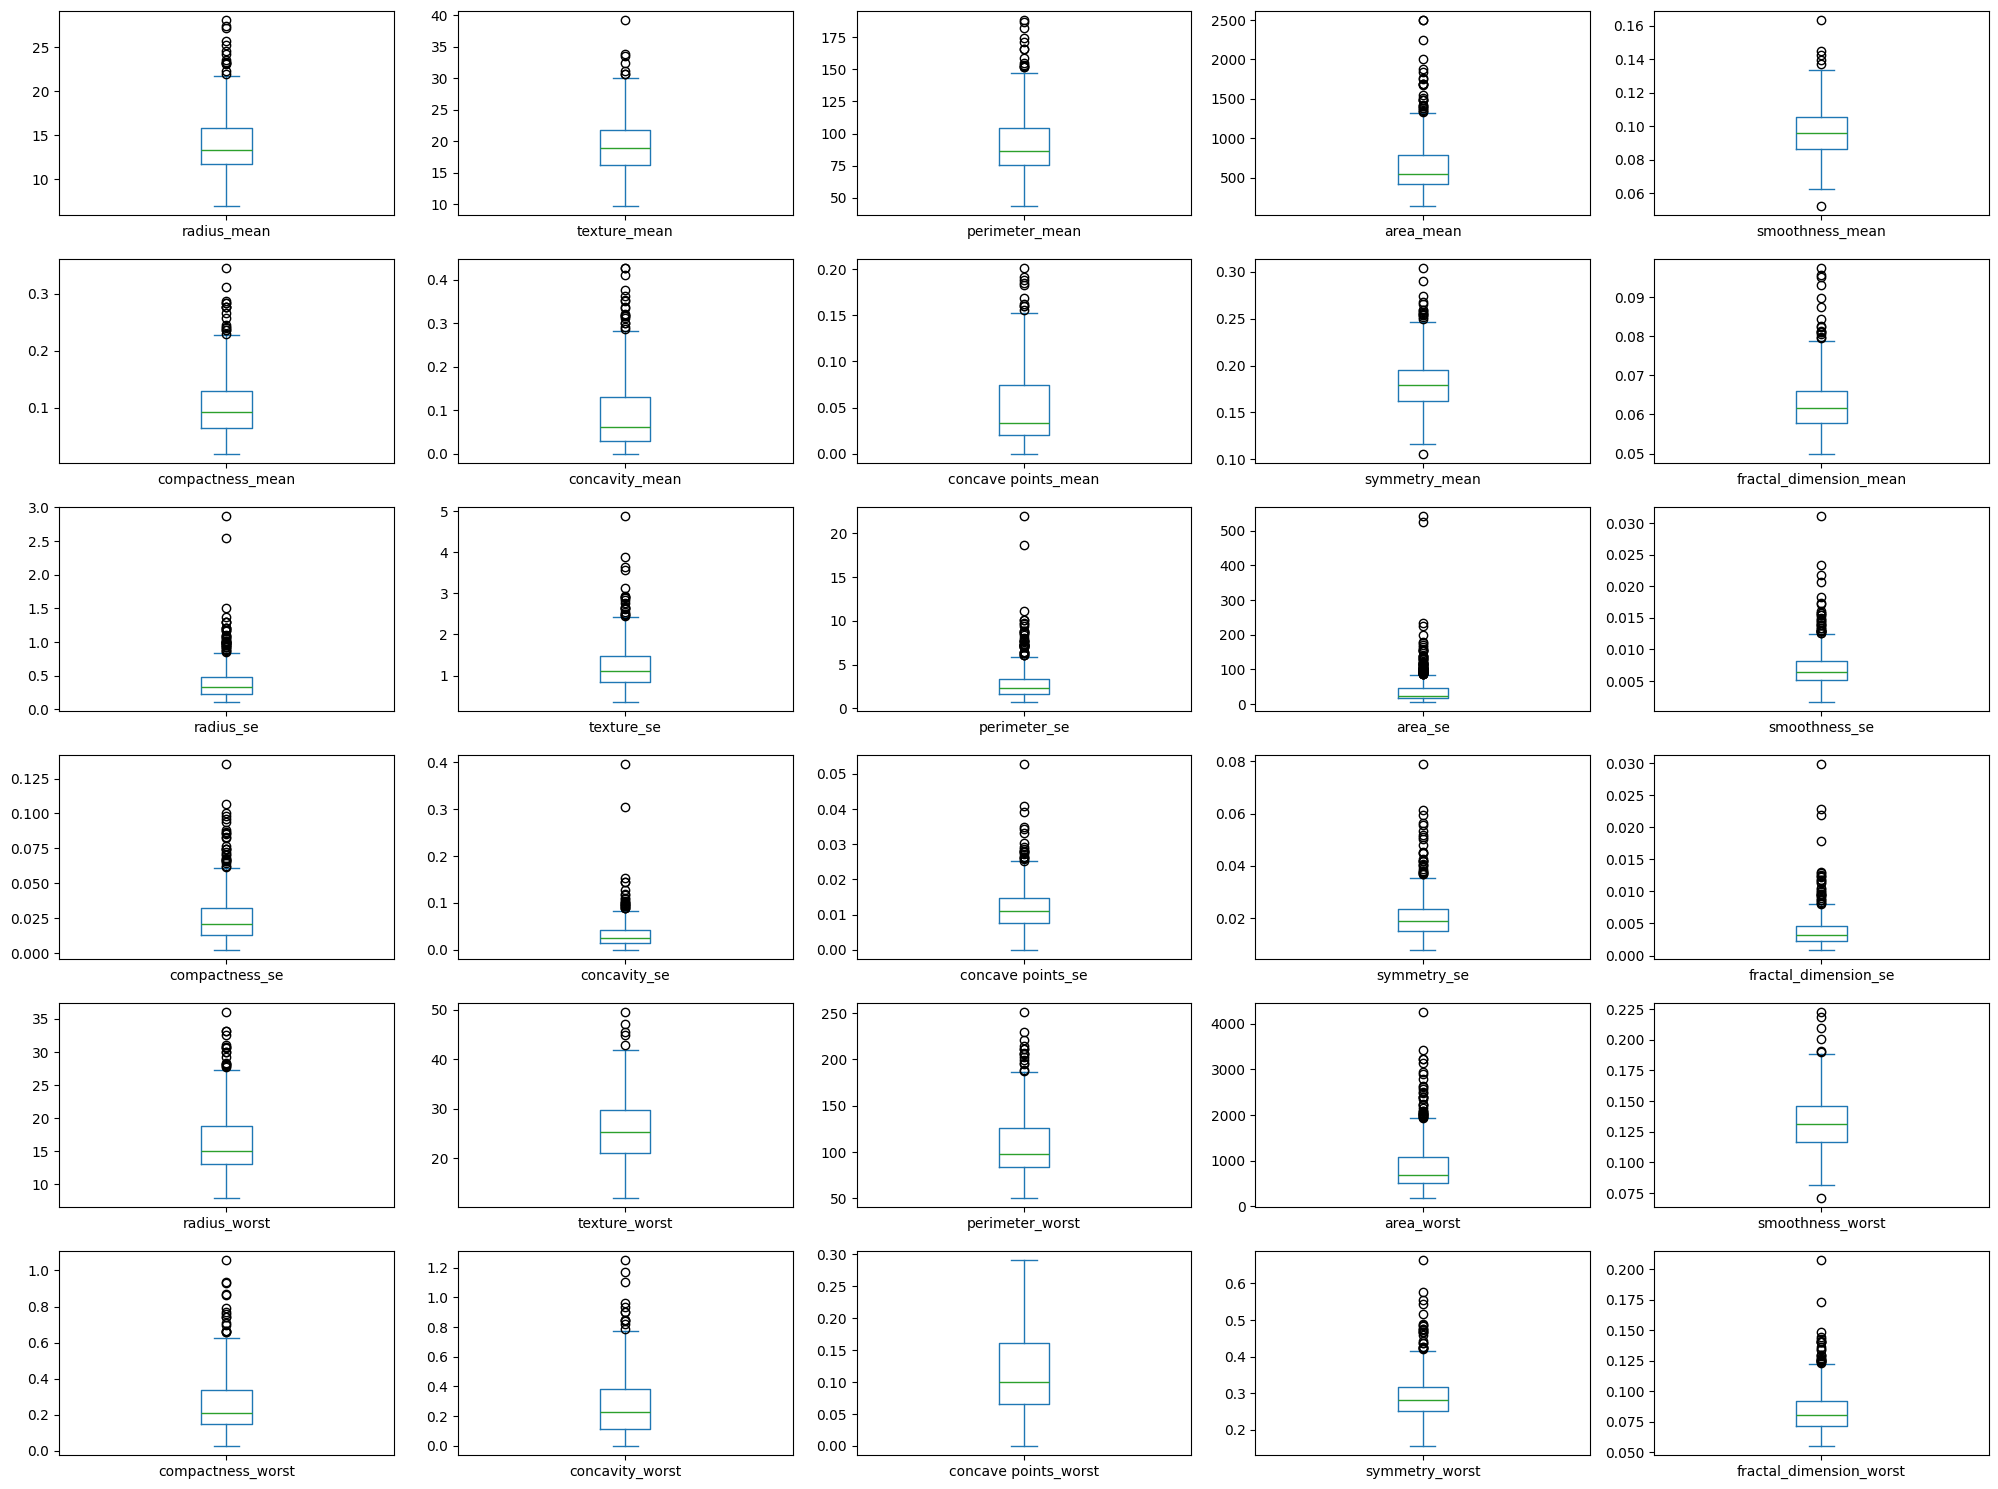

In [ ]:
# Plot boxplots to inspect outliers
df.drop('diagnosis', axis=1).plot(kind='box', subplots=True, layout=(6,5), figsize=(20,15), sharex=False, sharey=False)
plt.tight_layout()
plt.show()


In [ ]:
# Detect outliers
Q1 = df.drop('diagnosis', axis=1).quantile(0.25)
Q3 = df.drop('diagnosis', axis=1).quantile(0.75)
IQR = Q3 - Q1

# Filter
df_no_outliers = df[~((df.drop('diagnosis', axis=1) < (Q1 - 1.5 * IQR)) |
                      (df.drop('diagnosis', axis=1) > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Original shape: {df.shape}")
print(f"After outlier removal: {df_no_outliers.shape}")


Original shape: (569, 31)
After outlier removal: (398, 31)


In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
from sklearn.model_selection import train_test_split

X = df_no_outliers.drop('diagnosis', axis=1)
y = df_no_outliers['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predictions
y_pred = knn.predict(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Confusion Matrix:
 [[57  3]
 [ 2 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96        60
           1       0.86      0.90      0.88        20

    accuracy                           0.94        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.94      0.94      0.94        80

Accuracy: 0.9375


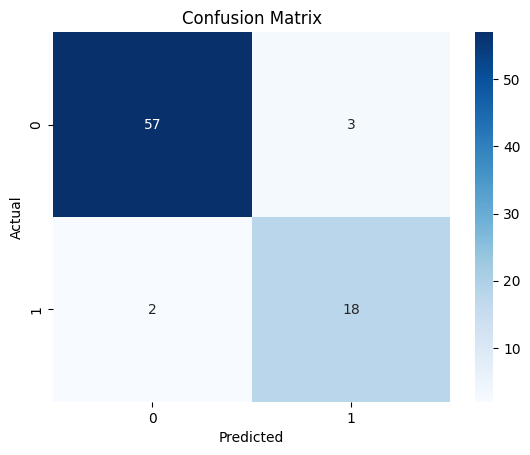

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
